# Exploratory data analysis

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

from festival_analysis.analysis_utils import query_db

In [2]:
%matplotlib inline

## Festivals

In [3]:
query_festivals = '''
SELECT 
  CAST(festival_id AS VARCHAR) AS festival_id,
  name,
  size_band,
  sb.description AS size_band_description
FROM festivals f
JOIN size_bands sb ON f.size_band = sb.label
'''

df_festivals = query_db(query_festivals)
df_festivals = df_festivals.set_index('festival_id')
df_festivals.info()
df_festivals.head()

<class 'pandas.core.frame.DataFrame'>
Index: 134 entries, 8868442761932147185 to 4337727016300241434
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   name                   134 non-null    object
 1   size_band              134 non-null    object
 2   size_band_description  134 non-null    object
dtypes: object(3)
memory usage: 4.2+ KB


,name,size_band,size_band_description
festival_id,,,
8868442761932147185,Lentekabinet,2 - S,"2,500 – 10,000"
3770262822180965878,Stone Techno,3 - M,"10,000 – 30,000"
3545183190061113930,XRDS,2 - S,"2,500 – 10,000"
7308788476028549761,memòri,1 - XS,"under 2,500"
41474036776617358,RIT/MO,1 - XS,"under 2,500"


In [4]:
df_festivals[['size_band', 'size_band_description']].drop_duplicates().sort_values('size_band')

,size_band,size_band_description
festival_id,,
7308788476028549761,1 - XS,"under 2,500"
8868442761932147185,2 - S,"2,500 – 10,000"
3770262822180965878,3 - M,"10,000 – 30,000"
584339127840213479,4 - L,"30,000 – 75,000"
6952660926306554150,5 - XL,"75,000+"


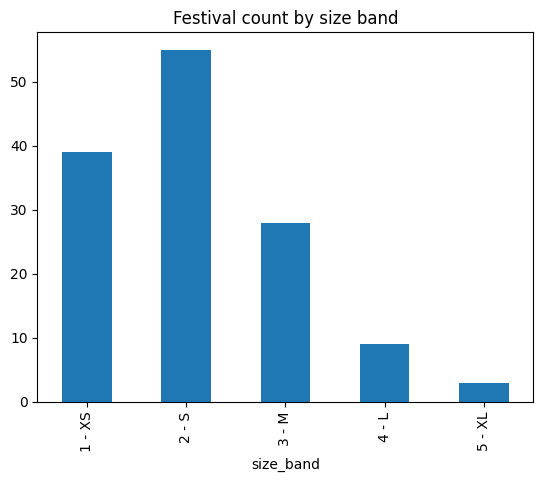

In [5]:
df_festivals.groupby('size_band').size().plot(kind='bar', title="Festival count by size band")
plt.show()

Most festivals in the dataset are on the smaller side: up to 10k. Only a few XL ones (75k+).

## Festival editions

In [6]:
query_festival_instances = '''
SELECT
  f.name||'-'||fe.edition_year AS edition_name,
  CAST(fe.festival_id AS VARCHAR) AS festival_id,
  f.name AS festival_name,
  fe.edition_year,
  f.size_band,
  fe.start_date,
  fe.end_date,
  c.continent AS location_continent,
  fe.location_country,
  fe.location_city
FROM
  festivals f
  LEFT JOIN editions fe USING(festival_id)
  LEFT JOIN countries c ON fe.location_country = c.country_name
'''

df_festival_editions = query_db(query_festival_instances)
df_festival_editions.set_index('edition_name', inplace=True)
df_festival_editions.info()
df_festival_editions.head()

<class 'pandas.core.frame.DataFrame'>
Index: 1020 entries, Body Movements-2022 to None
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   festival_id         1018 non-null   object        
 1   festival_name       1020 non-null   object        
 2   edition_year        1018 non-null   Int32         
 3   size_band           1020 non-null   object        
 4   start_date          1018 non-null   datetime64[us]
 5   end_date            1018 non-null   datetime64[us]
 6   location_continent  1018 non-null   object        
 7   location_country    1018 non-null   object        
 8   location_city       1018 non-null   object        
dtypes: Int32(1), datetime64[us](2), object(6)
memory usage: 76.7+ KB


,festival_id,festival_name,edition_year,size_band,start_date,end_date,location_continent,location_country,location_city
edition_name,,,,,,,,,
Body Movements-2022,2036115211852022434,Body Movements,2022,2 - S,2022-07-30,2022-07-30,Europe,United Kingdom,London
Butik-2019,4722574497284488166,Butik,2019,2 - S,2019-07-12,2019-07-12,Europe,Slovenia,All
Dekmantel-2023,8578965883151947907,Dekmantel,2023,3 - M,2023-01-27,2023-12-28,Europe,Netherlands,Amsterdam
Field Maneuvers-2019,5635464652128728794,Field Maneuvers,2019,1 - XS,2019-06-22,2019-08-30,Europe,United Kingdom,London
Gala-2022,2919907375839432406,Gala,2022,3 - M,2022-05-11,2022-12-08,Europe,United Kingdom,London


In [ ]:
# Save top countries for filtering later
n_countries = 10
top_n_countries = df_festival_editions.groupby('location_country').size().sort_values(ascending=False).index[:n_countries]

### Geo-based

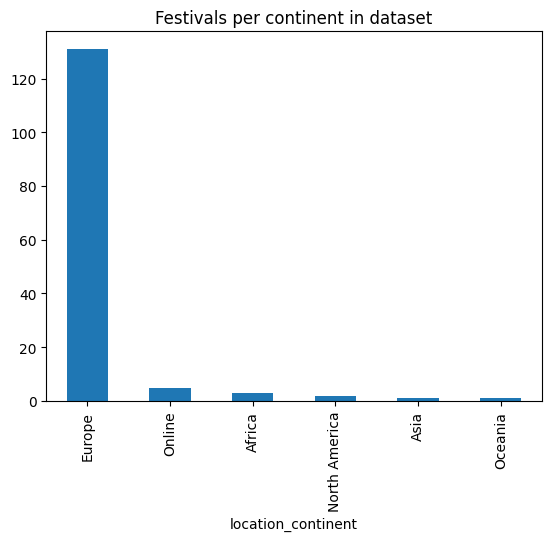

In [8]:
df_festival_editions.groupby('location_continent')['festival_id'].nunique().sort_values(ascending=False).plot(kind='bar', title='Festivals per continent in dataset')
plt.show()

Overwhelmingly Europe-based dataset.

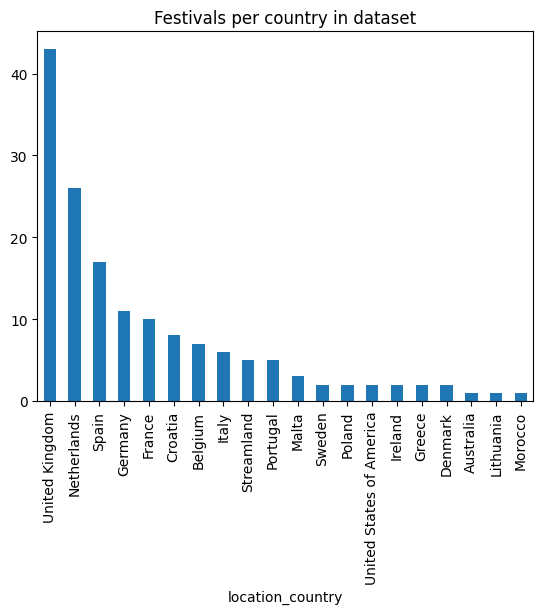

In [9]:
df_festival_editions.groupby('location_country')['festival_id'].nunique().sort_values(ascending=False).head(20).plot(kind='bar', title='Festivals per country in dataset')
plt.show()

Western Europe is leading with the UK and Netherlands dominating. Croatia is a classic festival destination for Western Europeans. 

### Time-based

In [14]:
df_festivals['years'] = df_festival_editions.groupby('festival_id')['edition_year'].nunique()
df_festival_editions['month'] = df_festival_editions['start_date'].dt.month
df_festival_editions['dayofyear'] = df_festival_editions['start_date'].dt.dayofyear

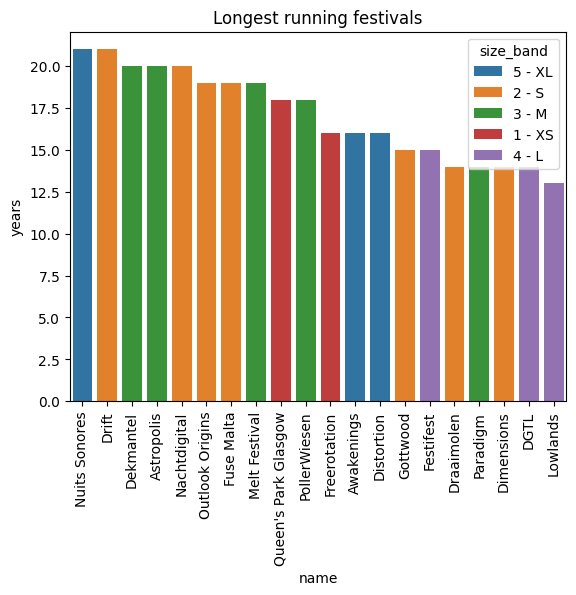

In [15]:
years_by_festival_and_size = df_festivals.groupby(['name', 'size_band'])['years'].max().reset_index().sort_values('years', ascending=False).head(20)
sns.barplot(data=years_by_festival_and_size, x='name', y='years', hue='size_band')
plt.xticks(rotation=90)
plt.title('Longest running festivals')
plt.show()

Some interesting ones in here that I hadn't heard of.

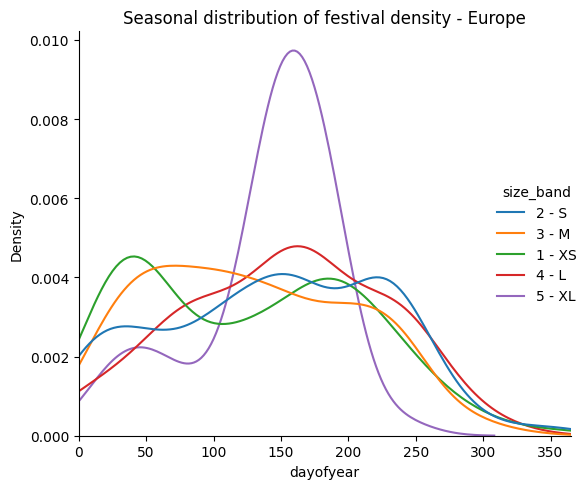

In [16]:
sns.displot(df_festival_editions.query('location_continent == "Europe"'), x='dayofyear', hue='size_band', kind='kde', common_norm=False)
plt.gca().set_xlim(0, 365)
plt.title('Seasonal distribution of festival density - Europe')
plt.tight_layout()
plt.show()

Interesting that the XL festivals pretty much all happen around the solstice while others are much more distributed (until October when nothing happens).

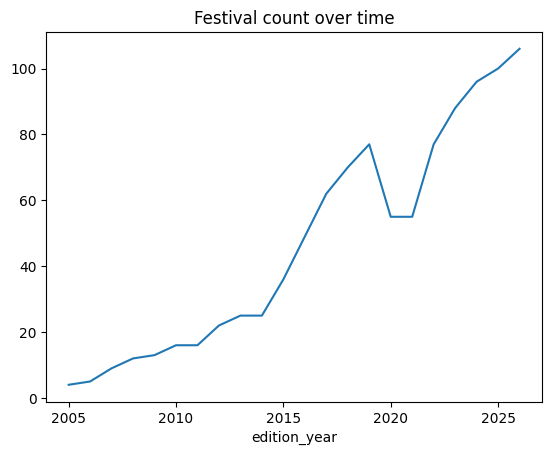

In [17]:
df_festival_editions.groupby('edition_year').size().plot(title='Festival count over time')
plt.show()

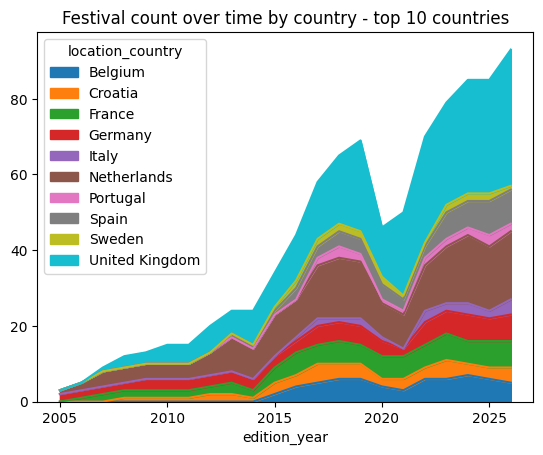

In [18]:
df_festival_editions.query('location_country.isin(@top_n_countries)').groupby(['edition_year', 'location_country']).size().unstack('location_country').plot(kind='area', title=f'Festival count over time by country - top {n_countries} countries')
plt.show()

Belgium coming in as a strong late entry.

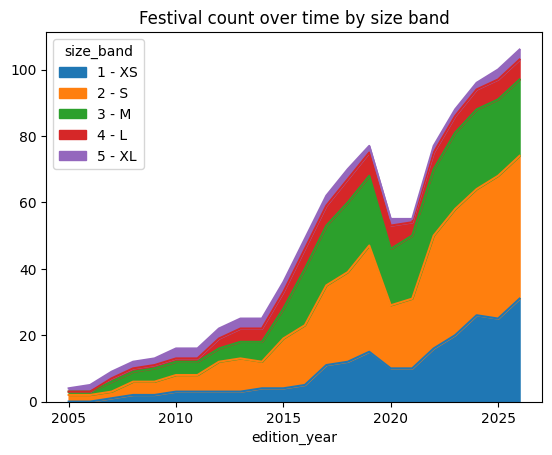

In [19]:
df_festival_editions.groupby(['edition_year', 'size_band']).size().unstack('size_band').plot(kind='area', title='Festival count over time by size band')
plt.show()

Most growth has been in XS to M festival sizes, not many new huge ones over the years.